# Gradient Descent - Parameters Analysis

In this notebook we test the gradient descent on two 2D functions:
1. A simple convex function
2. A more complex non-convex function

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from Algorithm.Classical_Algorithm.Gradient_descent import gradient_descent, numerical_gradient

## Function 1: Simple convex function

f(x, y) = x² + y²

Interval: x in [-5, 5], y in [-5, 5]

The minimum is at (0, 0) with f(0,0) = 0.

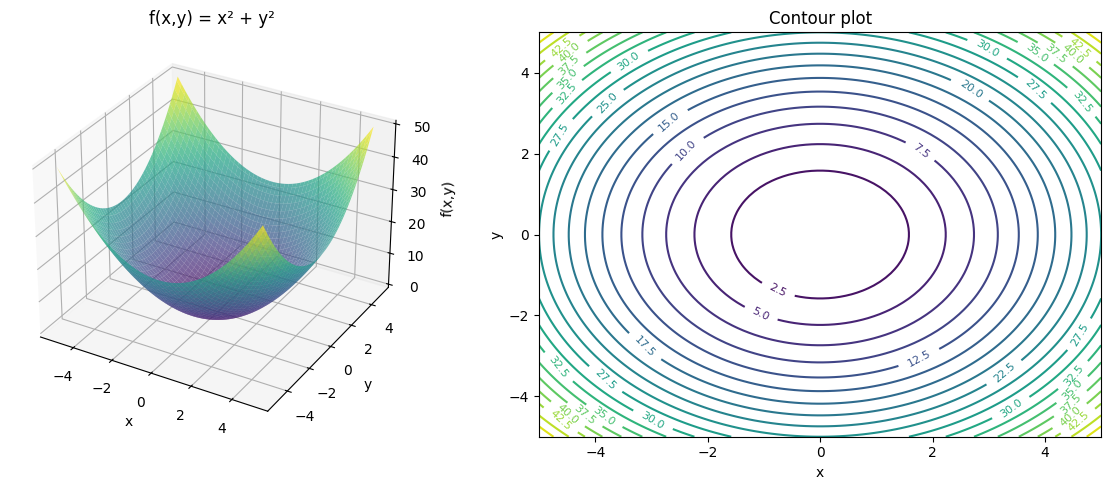

In [2]:
# Define the simple convex function
def f1(x, y):
    return x**2 + y**2

def grad_f1(x, y):
    return 2*x, 2*y

# Plot the landscape
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f1(X, Y)

fig = plt.figure(figsize=(12, 5))

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('f(x,y) = x² + y²')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour plot')

plt.tight_layout()
plt.show()

Starting point: (4.0000, 3.0000), f = 25.0000
Final point: (0.0000, 0.0000), f = 0.0000
Number of iterations: 93


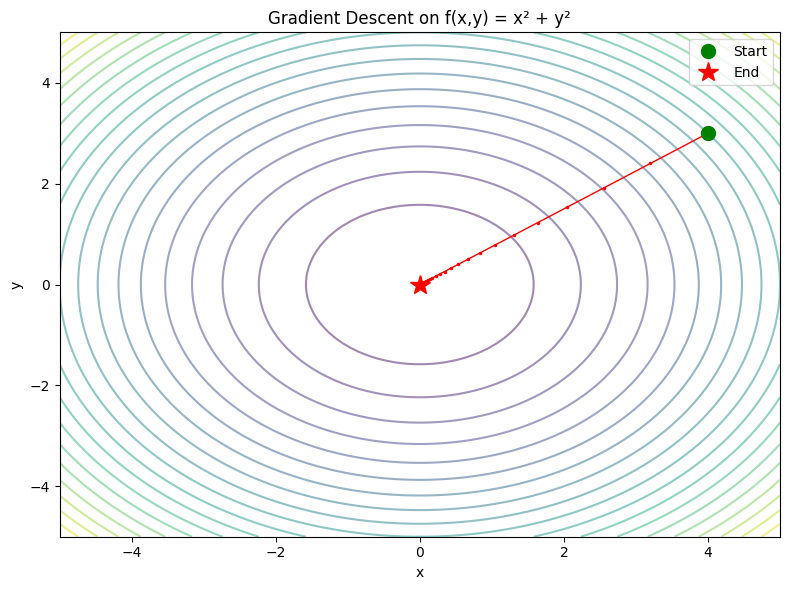

In [3]:
# Run gradient descent on f1
x_hist, y_hist, f_hist = gradient_descent(f1, grad_f1, x0=4.0, y0=3.0,
                                           learning_rate=0.1, n_iterations=100)

print(f"Starting point: ({x_hist[0]:.4f}, {y_hist[0]:.4f}), f = {f_hist[0]:.4f}")
print(f"Final point: ({x_hist[-1]:.4f}, {y_hist[-1]:.4f}), f = {f_hist[-1]:.4f}")
print(f"Number of iterations: {len(x_hist) - 1}")

# Plot the path
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=20, alpha=0.5)
plt.plot(x_hist, y_hist, 'r.-', markersize=3, linewidth=1)
plt.plot(x_hist[0], y_hist[0], 'go', markersize=10, label='Start')
plt.plot(x_hist[-1], y_hist[-1], 'r*', markersize=15, label='End')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent on f(x,y) = x² + y²')
plt.legend()
plt.tight_layout()
plt.show()

## Function 2: Non-convex function (Rastrigin-like)

f(x, y) = x² + y² + 10*(2 - cos(2*pi*x) - cos(2*pi*y))

Interval: x in [-5, 5], y in [-5, 5]

This function has many local minima.

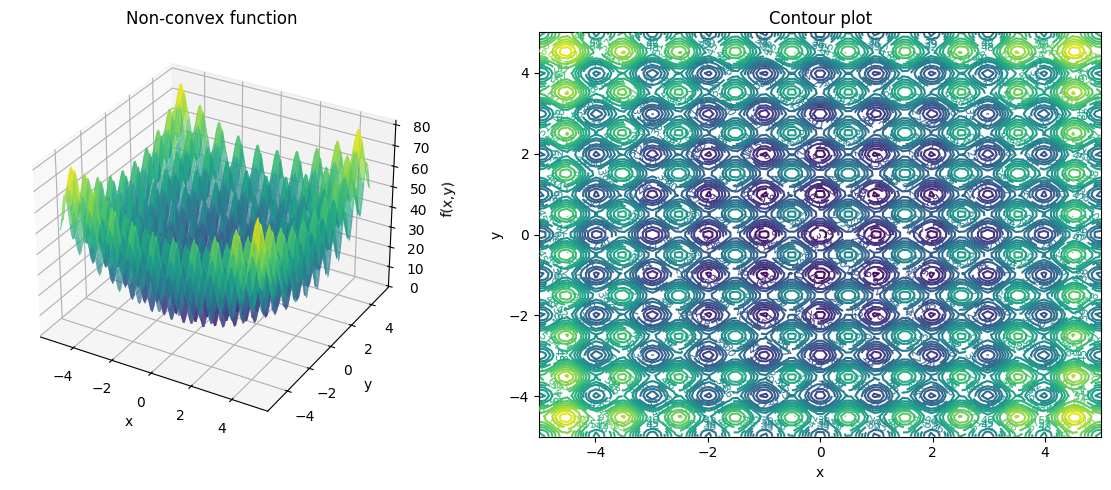

In [4]:
def f2(x, y):
    return x**2 + y**2 + 10*(2 - np.cos(2*np.pi*x) - np.cos(2*np.pi*y))

def grad_f2(x, y):
    dfdx = 2*x + 10 * 2 * np.pi * np.sin(2*np.pi*x)
    dfdy = 2*y + 10 * 2 * np.pi * np.sin(2*np.pi*y)
    return dfdx, dfdy

Z2 = f2(X, Y)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z2, cmap='viridis', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Non-convex function')

ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z2, levels=30)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour plot')

plt.tight_layout()
plt.show()

Starting point: (3.5000, 2.5000), f = 58.5000
Final point: (2.984856, 1.989912), f = 12.934432
Number of iterations: 57


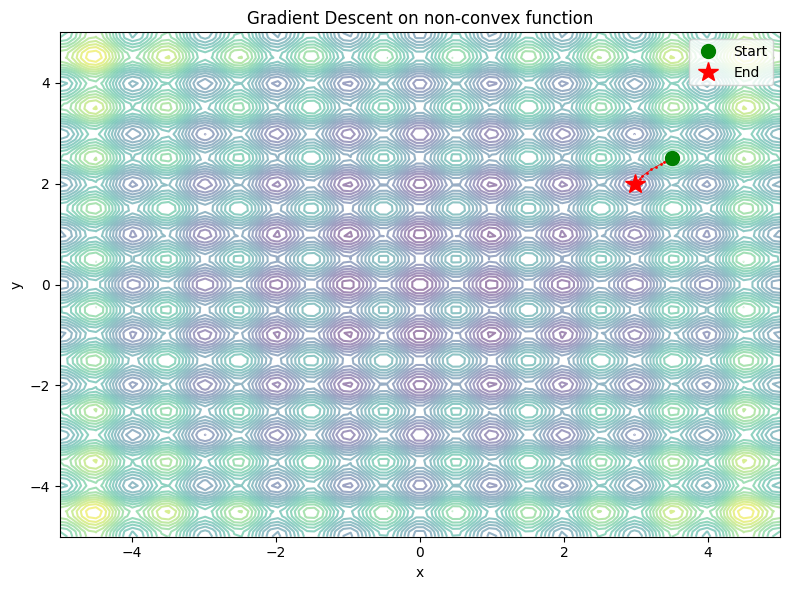


Note: Gradient descent gets stuck in a local minimum for the non-convex function!
This is because gradient descent only follows the local gradient and cannot escape local minima.


In [5]:
# Run gradient descent on the non-convex function
x_hist2, y_hist2, f_hist2 = gradient_descent(f2, grad_f2, x0=3.5, y0=2.5,
                                               learning_rate=0.001, n_iterations=2000)

print(f"Starting point: ({x_hist2[0]:.4f}, {y_hist2[0]:.4f}), f = {f_hist2[0]:.4f}")
print(f"Final point: ({x_hist2[-1]:.6f}, {y_hist2[-1]:.6f}), f = {f_hist2[-1]:.6f}")
print(f"Number of iterations: {len(x_hist2) - 1}")

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z2, levels=30, alpha=0.5)
plt.plot(x_hist2, y_hist2, 'r.-', markersize=2, linewidth=0.5)
plt.plot(x_hist2[0], y_hist2[0], 'go', markersize=10, label='Start')
plt.plot(x_hist2[-1], y_hist2[-1], 'r*', markersize=15, label='End')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent on non-convex function')
plt.legend()
plt.tight_layout()
plt.show()

print("\nNote: Gradient descent gets stuck in a local minimum for the non-convex function!")
print("This is because gradient descent only follows the local gradient and cannot escape local minima.")

## Test different learning rates

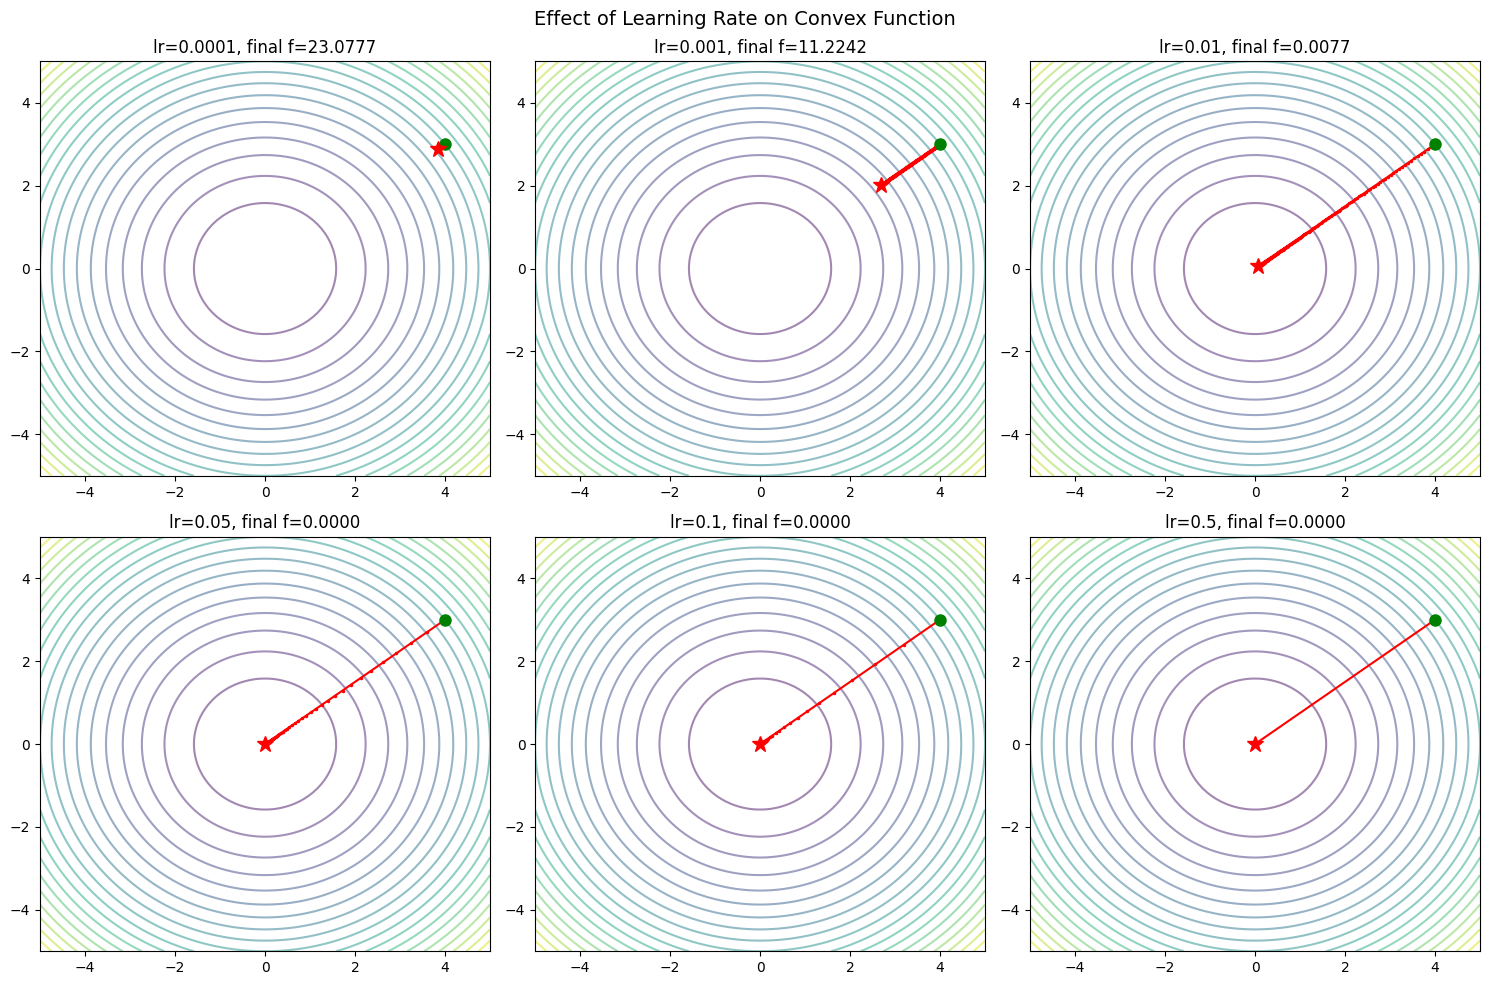

In [6]:
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, lr in enumerate(learning_rates):
    xh, yh, fh = gradient_descent(f1, grad_f1, x0=4.0, y0=3.0,
                                   learning_rate=lr, n_iterations=200)
    
    axes[i].contour(X, Y, Z, levels=20, alpha=0.5)
    axes[i].plot(xh, yh, 'r.-', markersize=3)
    axes[i].plot(xh[0], yh[0], 'go', markersize=8)
    axes[i].plot(xh[-1], yh[-1], 'r*', markersize=12)
    axes[i].set_title(f'lr={lr}, final f={fh[-1]:.4f}')
    axes[i].set_xlim(-5, 5)
    axes[i].set_ylim(-5, 5)

plt.suptitle('Effect of Learning Rate on Convex Function', fontsize=14)
plt.tight_layout()
plt.show()

## Test different learning rate schedules

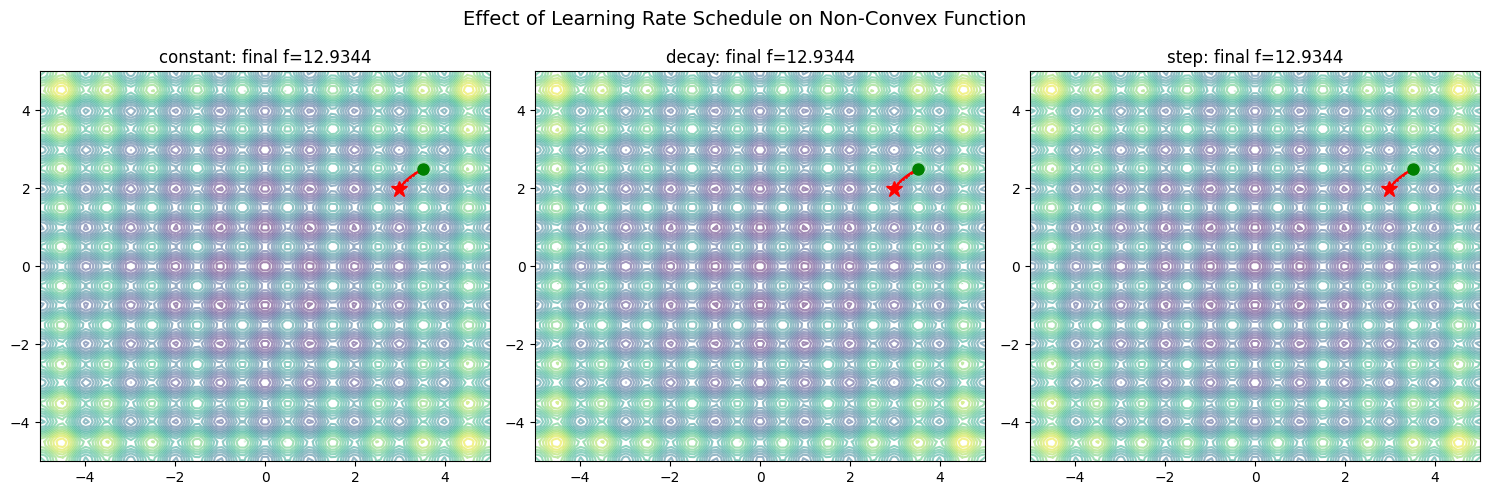

In [7]:
schedules = ["constant", "decay", "step"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, schedule in enumerate(schedules):
    xh, yh, fh = gradient_descent(f2, grad_f2, x0=3.5, y0=2.5,
                                   learning_rate=0.001, n_iterations=2000,
                                   lr_schedule=schedule)
    
    axes[i].contour(X, Y, Z2, levels=30, alpha=0.5)
    axes[i].plot(xh, yh, 'r.-', markersize=2)
    axes[i].plot(xh[0], yh[0], 'go', markersize=8)
    axes[i].plot(xh[-1], yh[-1], 'r*', markersize=12)
    axes[i].set_title(f'{schedule}: final f={fh[-1]:.4f}')
    axes[i].set_xlim(-5, 5)
    axes[i].set_ylim(-5, 5)

plt.suptitle('Effect of Learning Rate Schedule on Non-Convex Function', fontsize=14)
plt.tight_layout()
plt.show()

## Test with numerical gradient vs analytical

In [8]:
test_x, test_y = 2.0, 1.5

analytical = grad_f1(test_x, test_y)
numerical = numerical_gradient(f1, test_x, test_y)

print(f"Point : ({test_x}, {test_y})")
print(f"Analytical gradient : ({analytical[0]:.6f}, {analytical[1]:.6f})")
print(f"Numerical gradient : ({numerical[0]:.6f}, {numerical[1]:.6f})")
print(f"Difference : ({abs(analytical[0]-numerical[0]):.10f}, {abs(analytical[1]-numerical[1]):.10f})")

Point : (2.0, 1.5)
Analytical gradient : (4.000000, 3.000000)
Numerical gradient : (4.000000, 3.000000)
Difference : (0.0000000000, 0.0000000001)


## Test different delta values for numerical gradient

In [9]:
deltas = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-10]

print("Testing different delta values:")
print("Delta | grad_x | grad_y | error_x | error_y")
print("-" * 60)

analytical_gx, analytical_gy = grad_f1(test_x, test_y)

for delta in deltas:
    gx, gy = numerical_gradient(f1, test_x, test_y, delta=delta)
    err_x = abs(gx - analytical_gx)
    err_y = abs(gy - analytical_gy)
    print(f"{delta:.1e} | {gx:.8f} | {gy:.8f} | {err_x:.2e} | {err_y:.2e}")

Testing different delta values:
Delta | grad_x | grad_y | error_x | error_y
------------------------------------------------------------
1.0e-02 | 4.00000000 | 3.00000000 | 8.53e-14 | 1.95e-14
1.0e-03 | 4.00000000 | 3.00000000 | 4.41e-13 | 7.74e-13
1.0e-04 | 4.00000000 | 3.00000000 | 4.00e-12 | 1.89e-12
1.0e-05 | 4.00000000 | 3.00000000 | 2.62e-11 | 6.41e-11
1.0e-06 | 4.00000000 | 3.00000000 | 1.15e-10 | 4.69e-10
1.0e-07 | 4.00000000 | 3.00000000 | 2.11e-09 | 3.97e-09
1.0e-08 | 3.99999998 | 2.99999998 | 2.43e-08 | 1.82e-08
1.0e-10 | 4.00000033 | 3.00000025 | 3.31e-07 | 2.48e-07


## Conclusions

1. **Learning rate**: Too small = very slow convergence. Too large = oscillations or divergence. For the convex function, lr=0.1 works well. For the non-convex one, lr=0.001 is more stable.

2. **Learning rate schedule**: The `decay` schedule helps stabilize the descent towards the end. The `step` schedule provides periodic decreases.

3. **Delta for numerical gradient**: Values around 1e-5 to 1e-7 give the best accuracy. Too small (like 1e-10) causes numerical errors due to floating point precision.

4. **Convex vs non-convex**: Gradient descent works perfectly on convex functions but gets stuck in local minima on non-convex ones. This is why methods like simulated annealing exist.